### First attempt was at the following parameters: 
####   epochs=60,
####    imgsz=640,
####    batch=8, 

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': 'dataset',
      'train': 'images/train',
      'val': 'images/val',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = 'dataset/classes.txt'
path_to_data_yaml = 'dataset/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

import os
from pathlib import Path

def get_latest_run(base_dir, prefix="gun_detector"):
    """Automatically finds the most recently modified training run folder."""
    runs_path = Path(base_dir)
    folders = [f for f in runs_path.iterdir() if f.name.startswith(prefix) and f.is_dir()]
    latest = max(folders, key=lambda f: f.stat().st_mtime)
    return latest / "weights" / "best.pt"

base = r"C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\runs\detect"
best_weights = get_latest_run(base)
print(f"Using weights: {best_weights}")


Created config file at dataset/data.yaml


### Model Training Code - Run this to start
#### Parameters:
##### Number of epochs (epochs)

##### In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.

##### Resolution (imgsz)

##### Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if you want your model to run faster or know you will be working with low-resolution images, try using a lower resolution like 480x480.

In [ ]:
from ultralytics import YOLO

model = YOLO(str(best_weights))

model = YOLO("yolo11s.pt")

model.train(
    data=r"dataset/data.yaml",
    epochs=60,
    imgsz=640,
    batch=8,
    augment=True,
    name="gun_detector"
)

New https://pypi.org/project/ultralytics/8.4.66 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E1ACD652E0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

### Model Testing Code


#### The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.



image 1/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene1_12.png: 640x640 130 guns, 8.1ms
image 2/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene1_4.png: 640x640 128 guns, 9.5ms
image 3/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene1_5.png: 640x640 97 guns, 9.0ms
image 4/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene1_6.png: 640x640 125 guns, 10.7ms
image 5/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene2_19.png: 640x640 51 guns, 15.6ms
image 6/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene2_2.png: 640x640 40 guns, 17.0ms
image 7/29 C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val\Scene2_21.png: 640x640 30 guns, 15.4ms
image 8/29 C:\Users\Andrew\Documents\

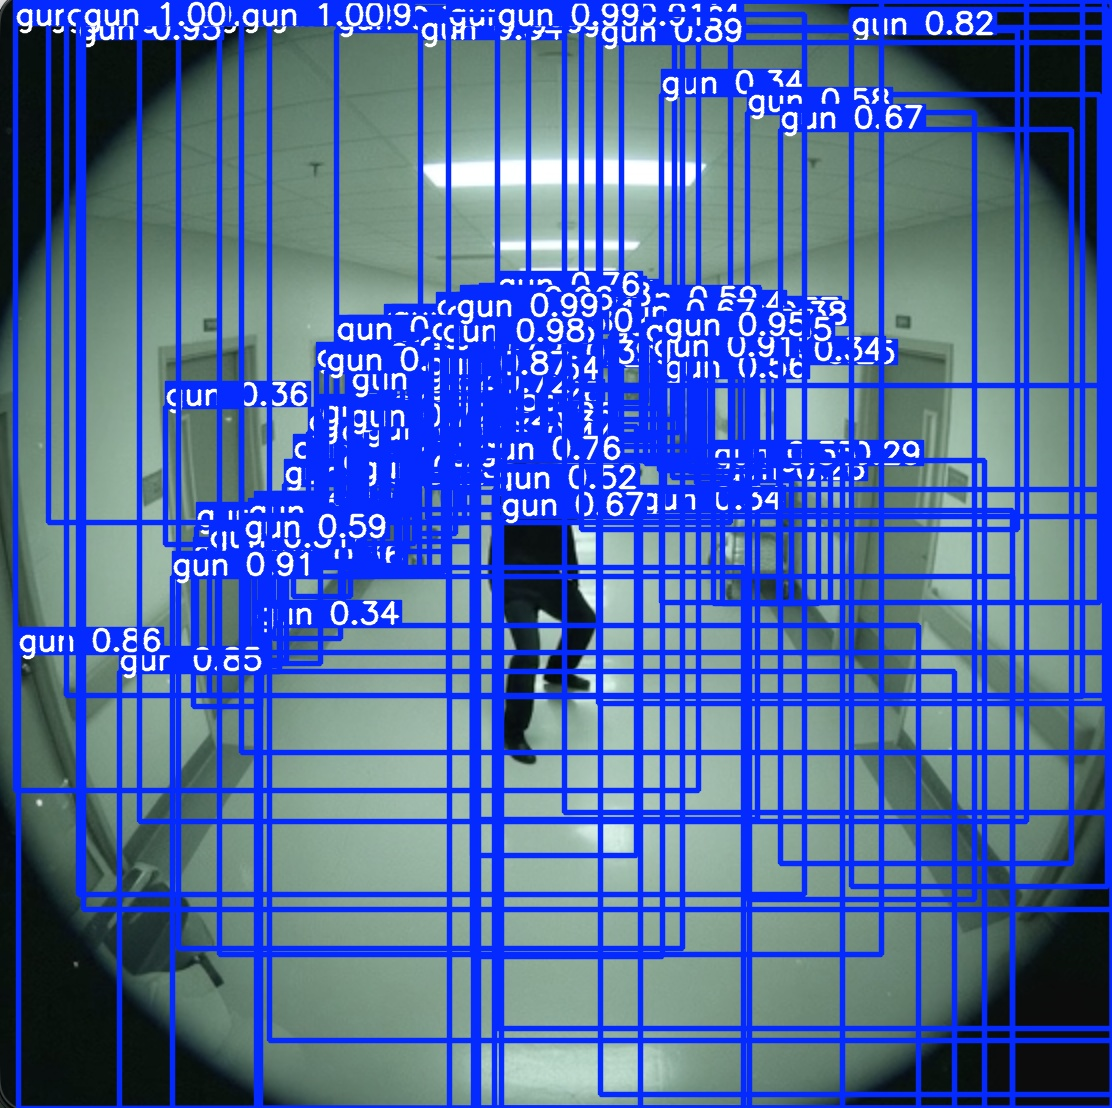

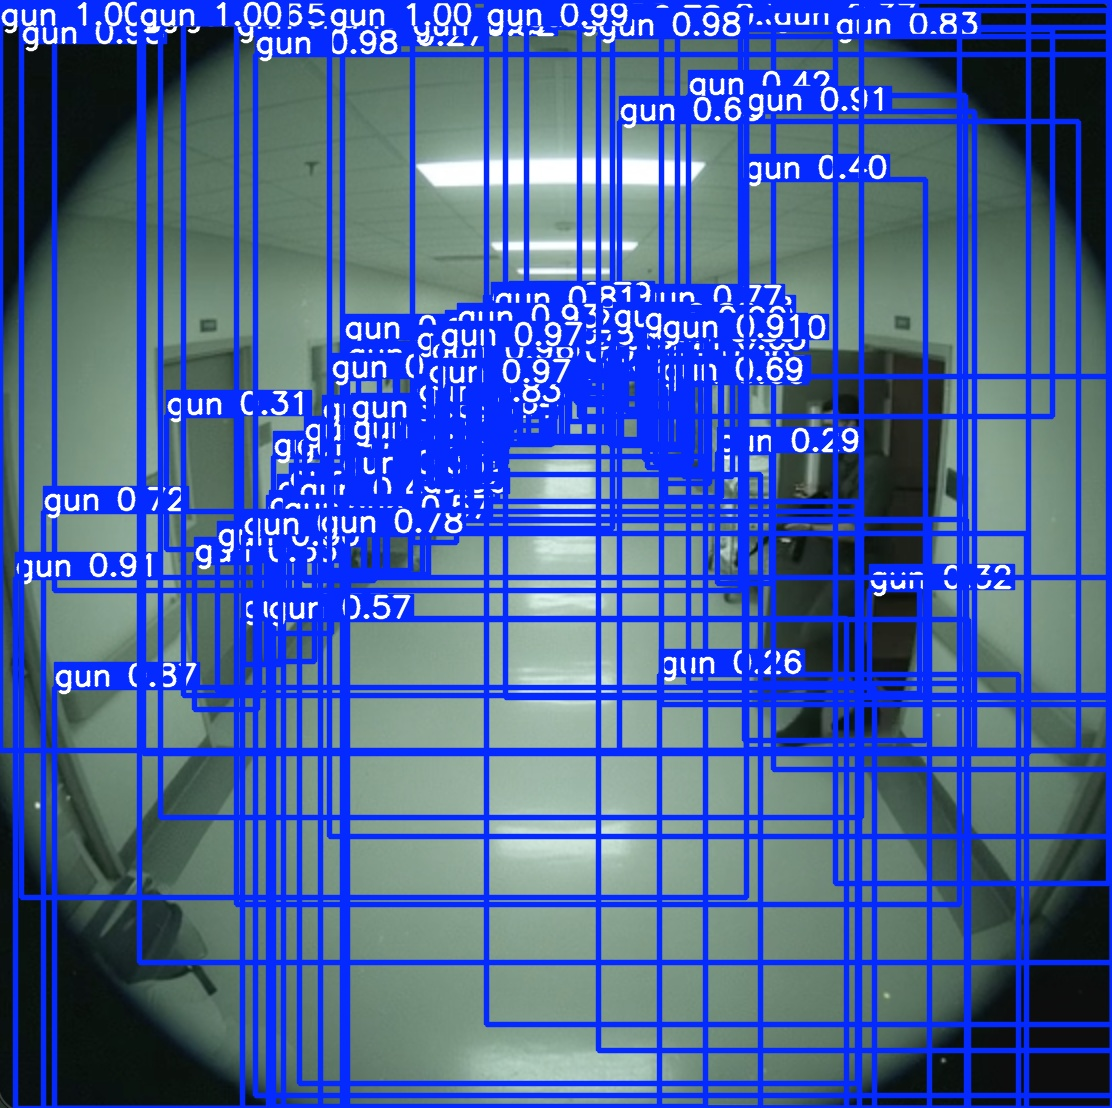

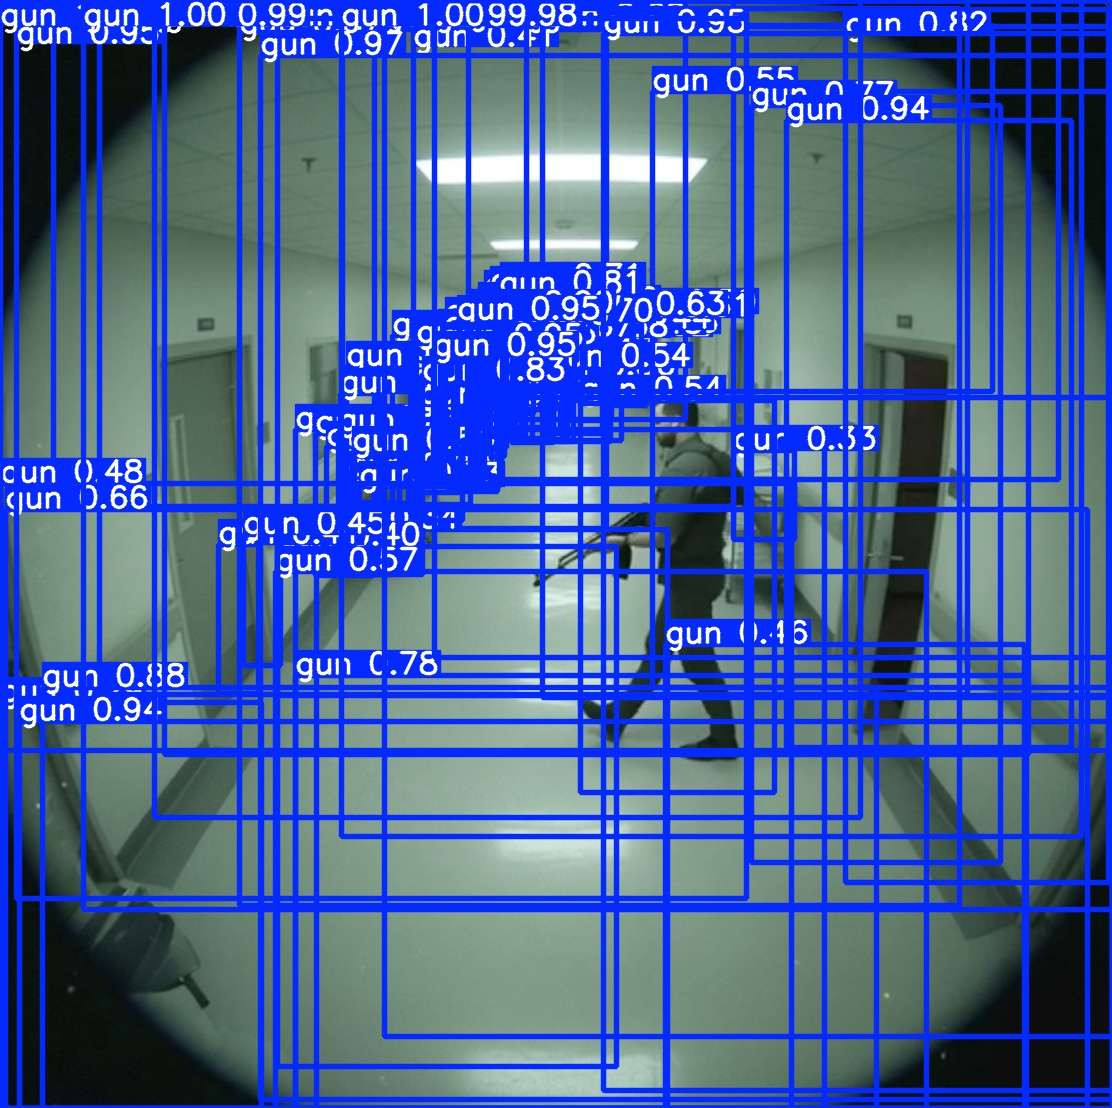

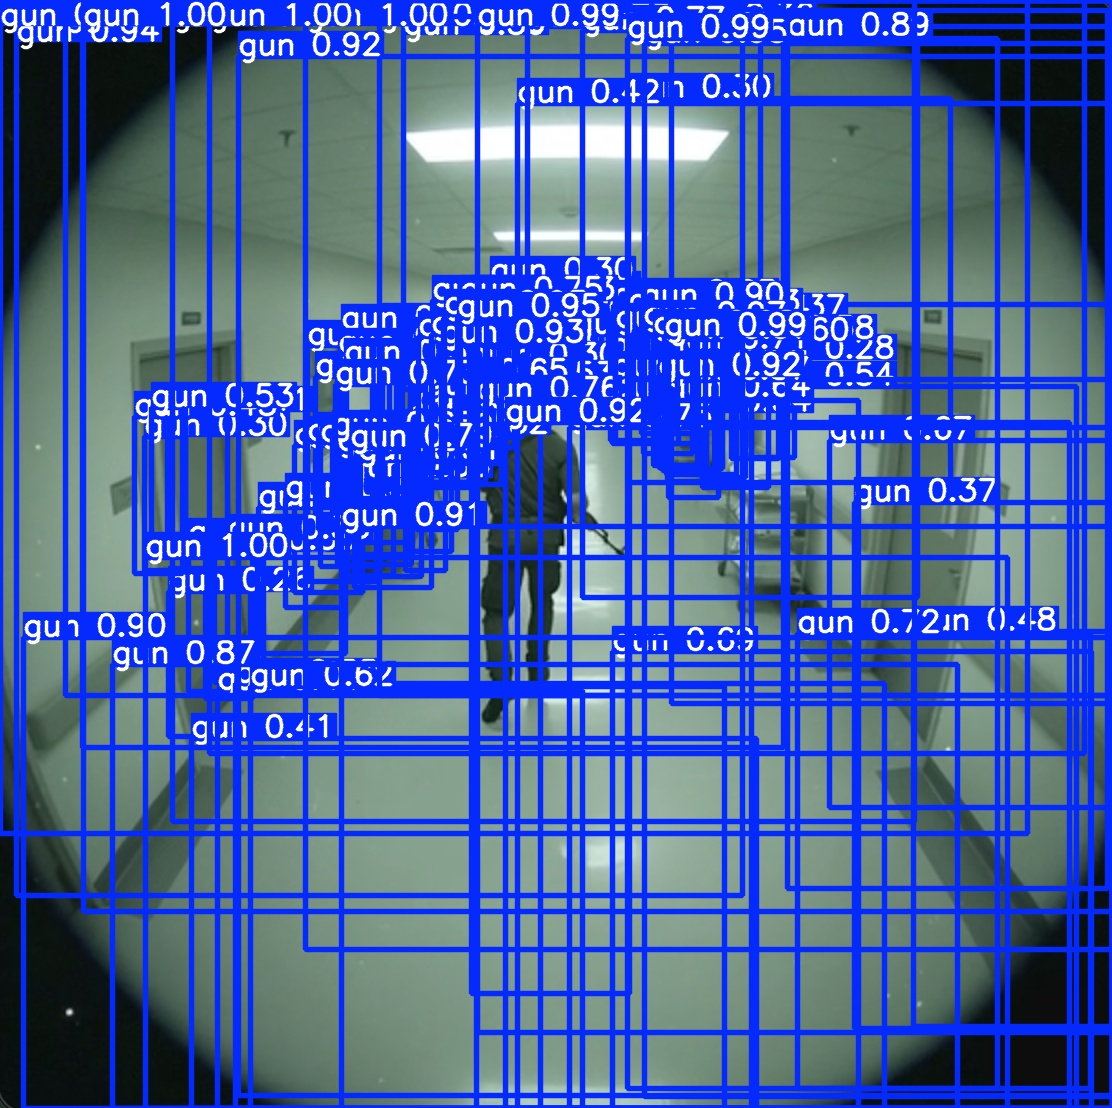

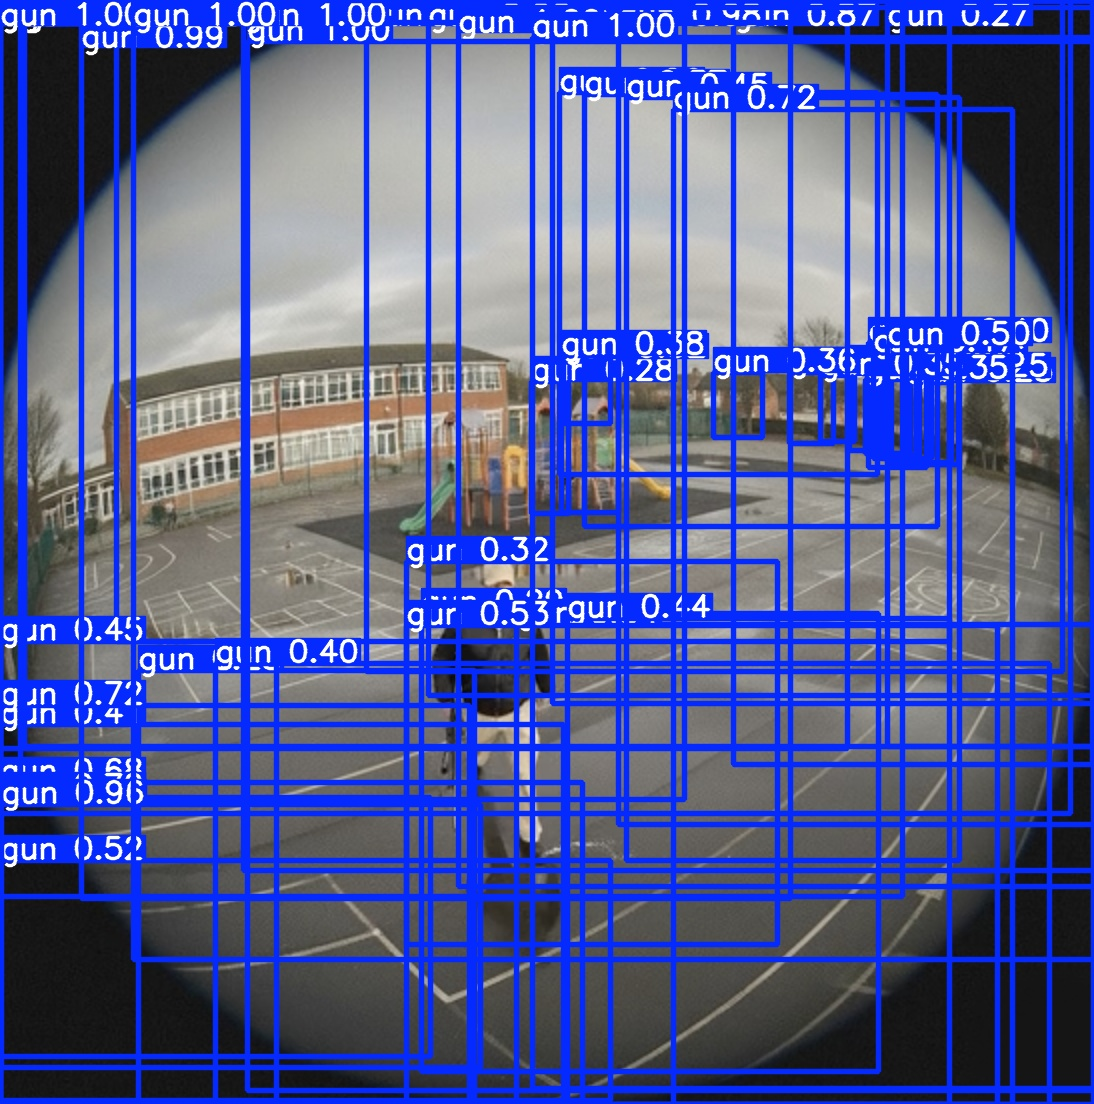

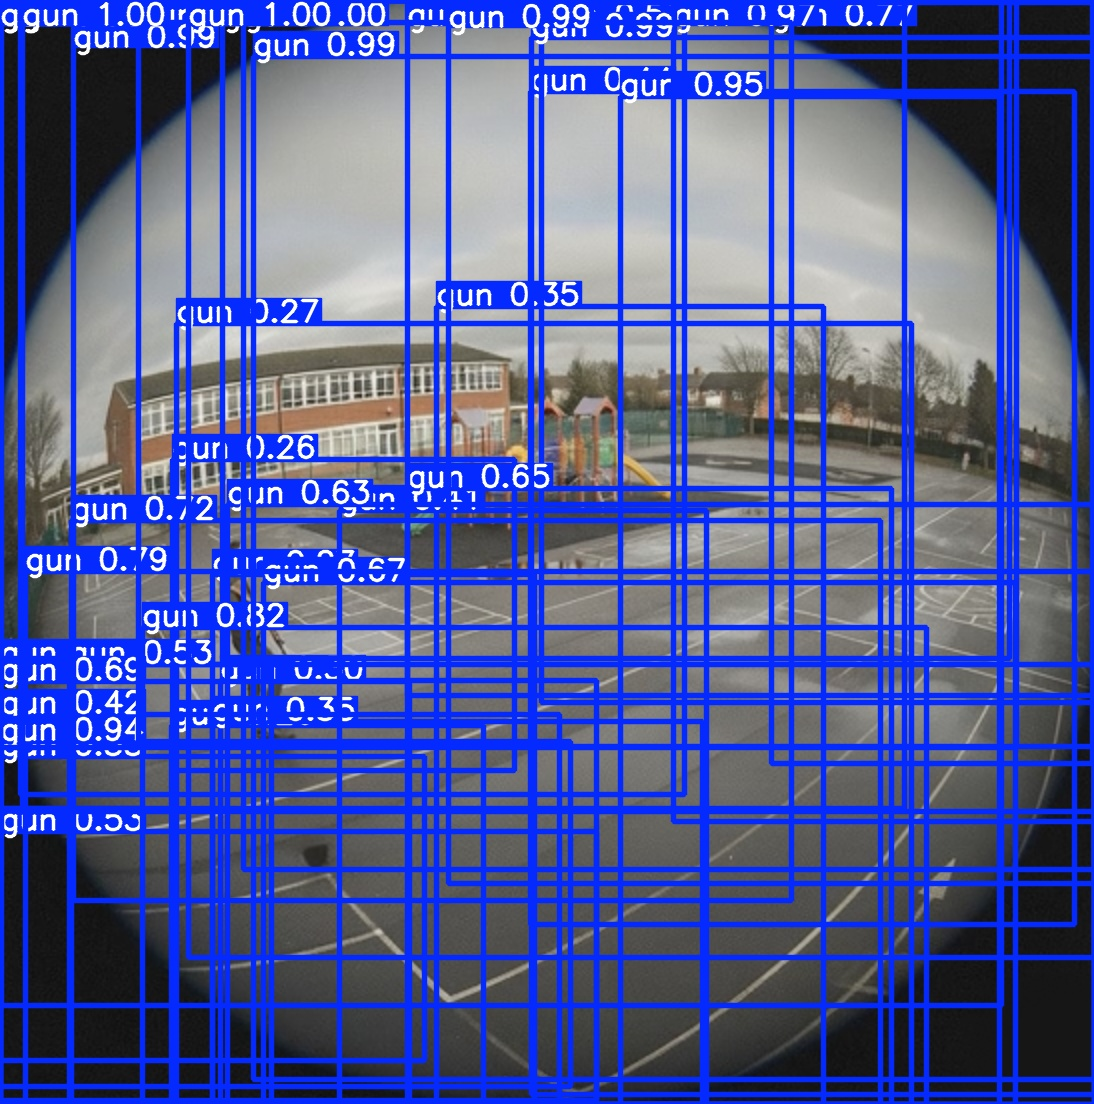

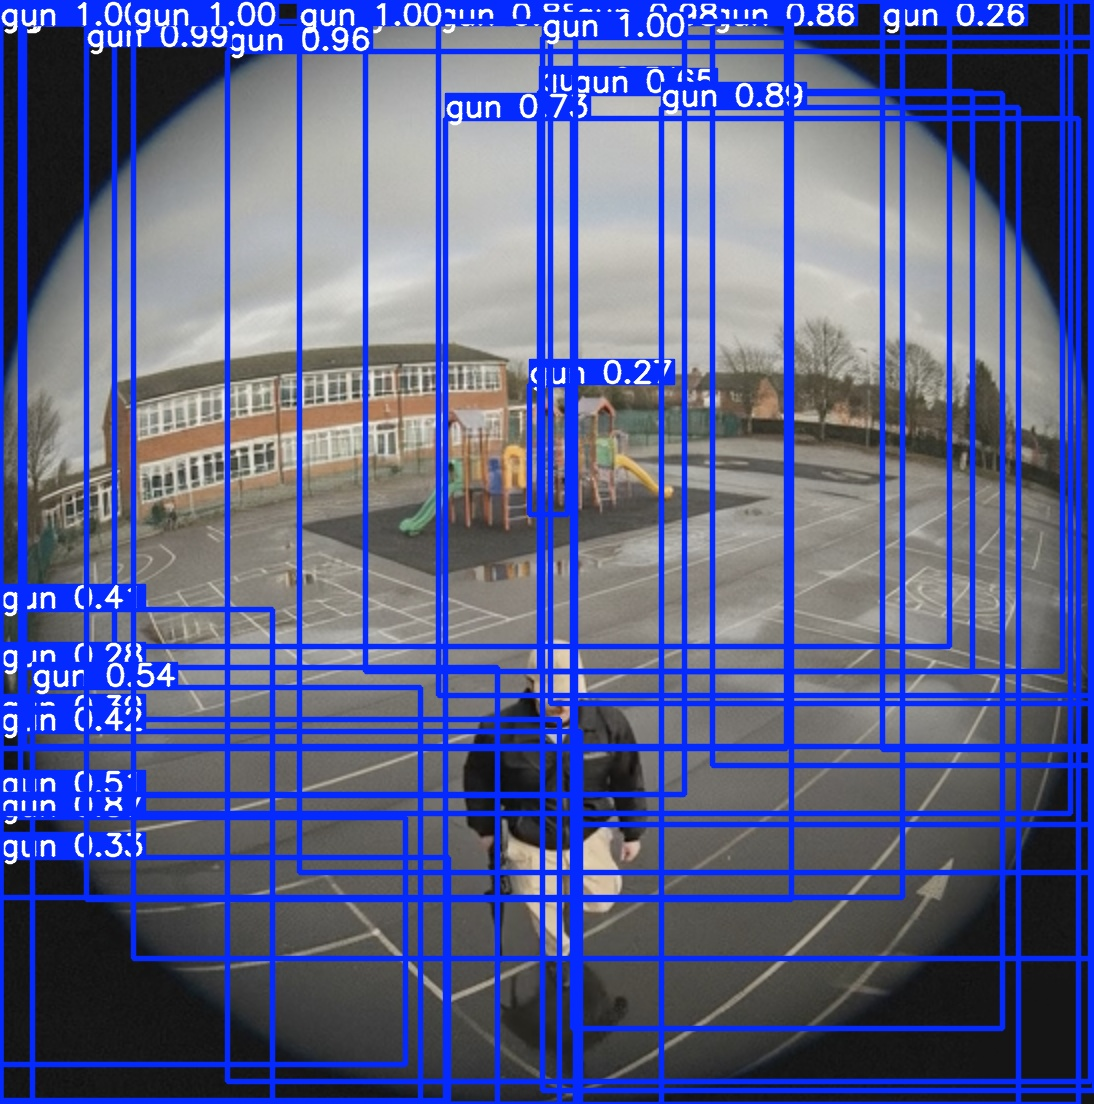

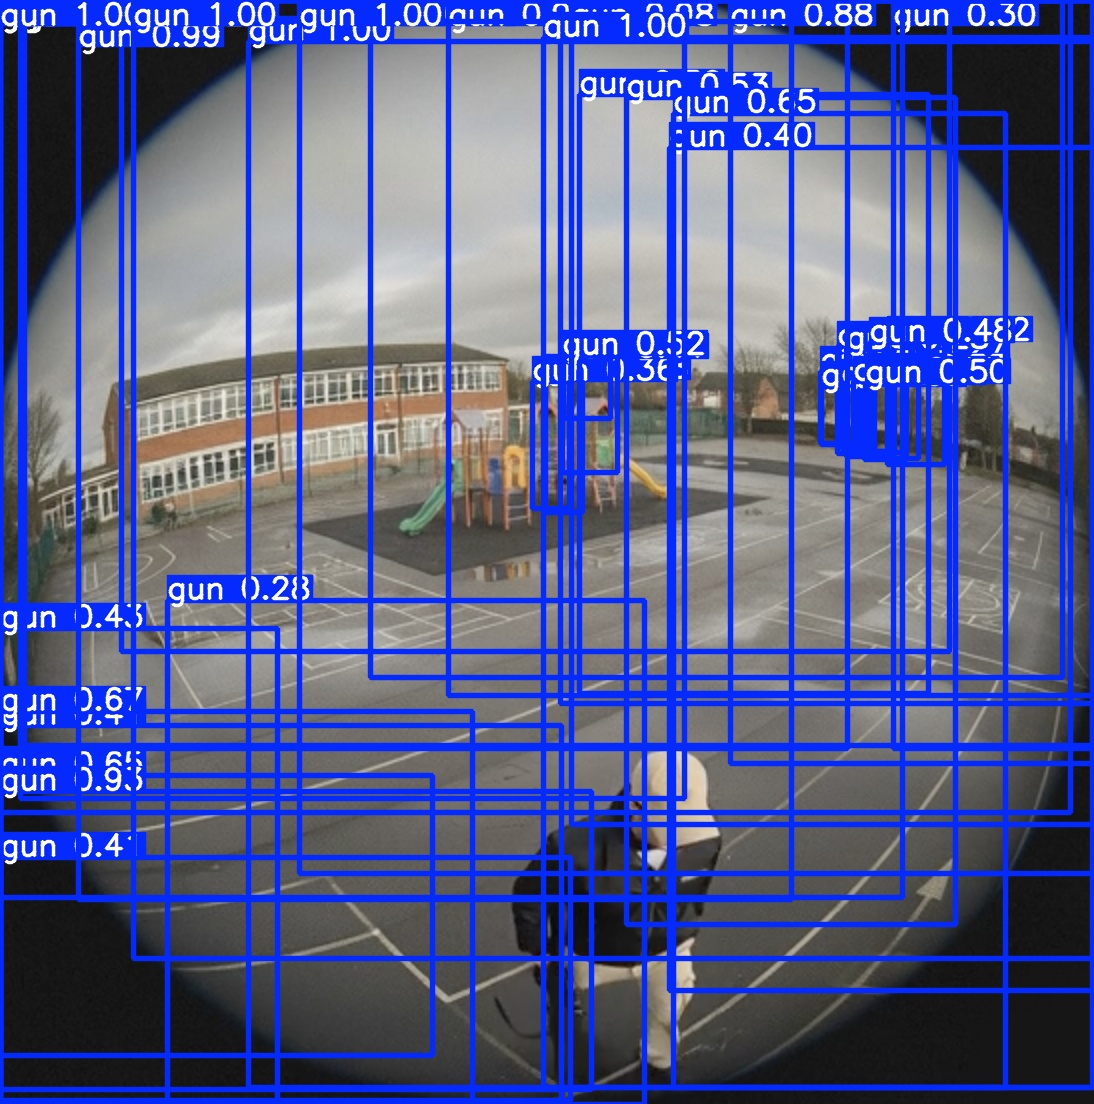

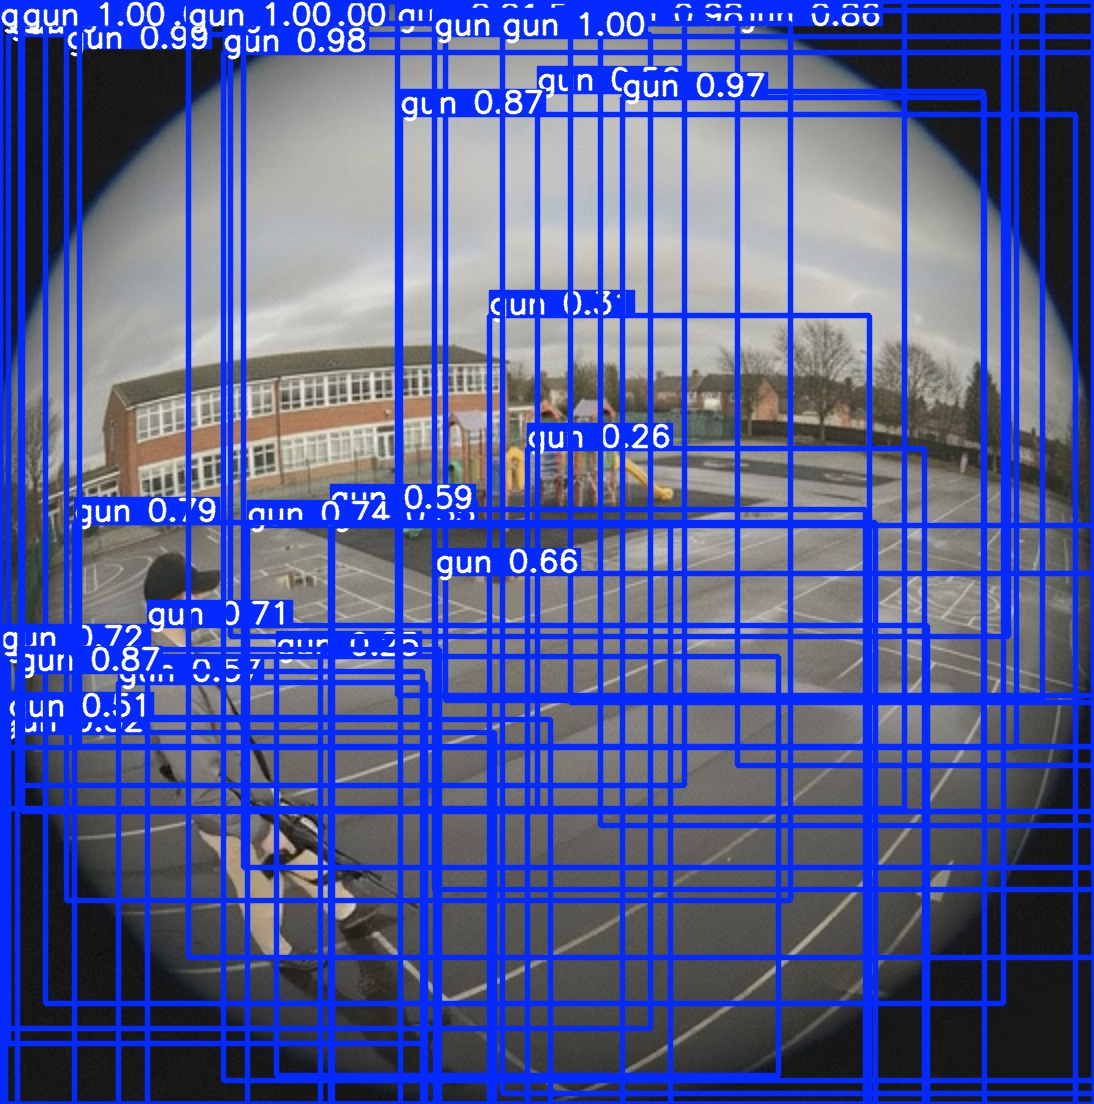

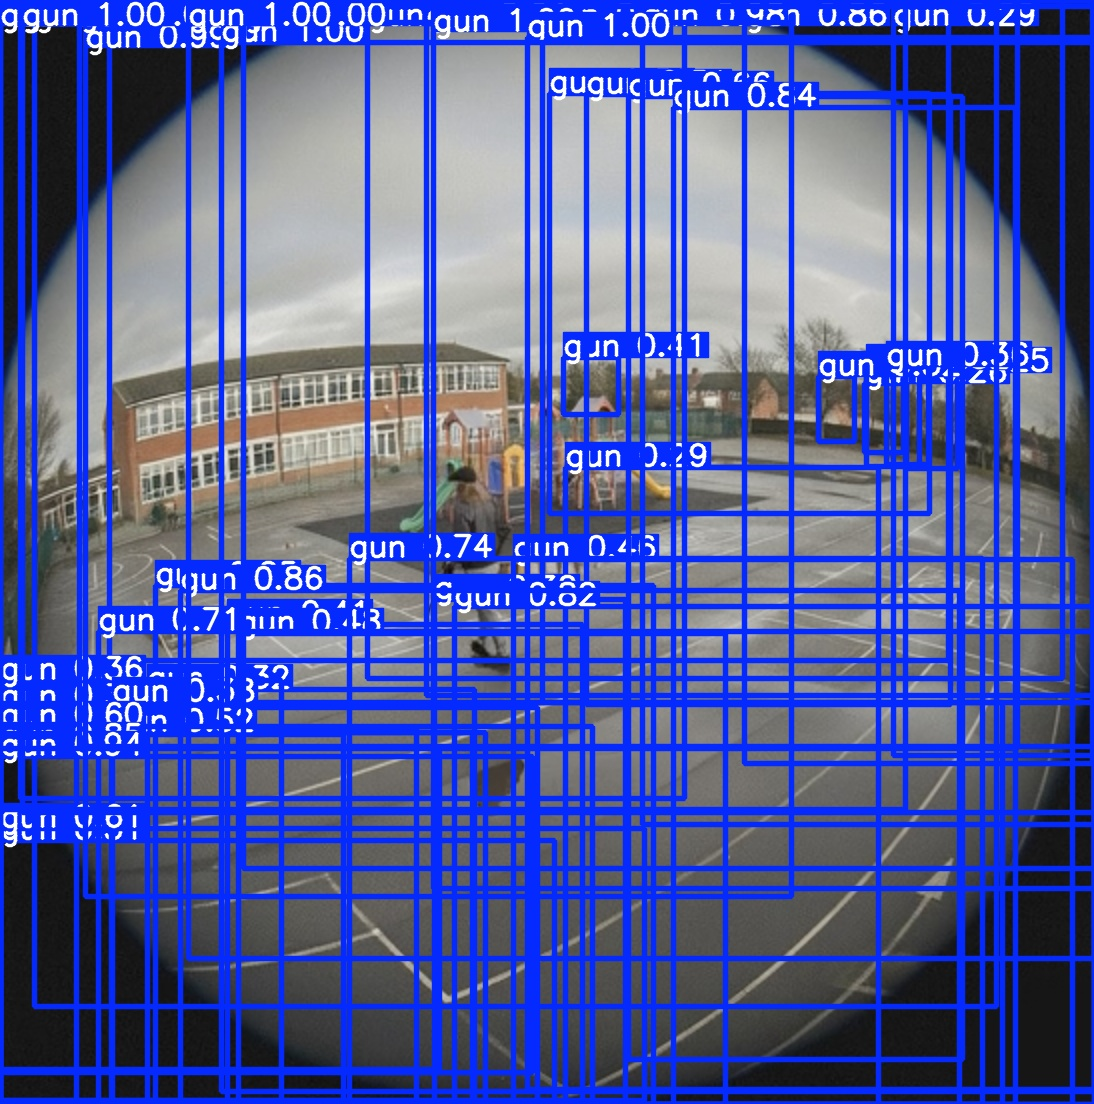

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

model = YOLO(str(best_weights))

# ── 1. Load your trained model ────────────────────────────────────────────────
model = YOLO(r"C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\runs\detect\gun_detector-9\weights\best.pt")

# ── 2. Run inference on your val images ───────────────────────────────────────
model.predict(
    source=r"C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\dataset\images\val",
    save=True,
    name="gun_detector_predict"
)

# ── 3. Display the first 10 results in the notebook ──────────────────────────
for image_path in glob.glob(r"C:\Users\Andrew\Documents\AI ML\Python AI ML Class Capstone\Capstone\runs\detect\gun_detector_predict\*.jpg")[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')